<a href="https://colab.research.google.com/github/Sigmbl4/titanic-survival-prediction/blob/main/titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Titanic Survival Prediction

## Описание проекта
Предсказание выживаемости пассажиров на основе датасета Titanic (Kaggle)

## Данные
- 891 пассажир, 12 признаков
- Целевая переменная: Survived(0 - погиб, 1 - выжил)

## Пропуски
Были пропуски в признаках 'Age', 'Cabin', 'Embarked'
- В "Age" заполнил пропуски медианой
- В "Embarked" заполнил пропуски самым часто встречающимся значением
- Признак "Cabin" удалил полностью, так как 687 значений из 891 являются пустыми, то есть признак считается бесполезным

## EDA
- Первый график: женщины выживали почти в 3.9 раза чаще мужчин (~74% vs ~19%)
- Второй график: Выживаемость 1-ого класса примерно в 2.6 раза выше 3-ого (~63% vs ~24%)
- Третий график: большинство пассажиров были молодые люди 20-35 лет
- Четвертый график: медианный возраст выживших и погибших почти одинаковый, но у погибших больше выбросов среди пожилых

## Feature Engineering
Создал признаки "Title", "FamilySize"
- "Title": вычленили из имени, титул очень сильно коррелирует с полом и возрастом, признаки "Sex" и "Name" можно будет удалить, так как вся полезная информация о них будет уже в титуле, но "Age" нельзя, потому что точный возраст сказать будет нельзя по титулу
- "FamilySize" : соединил признаки "SibSp" и "Parch", так же не забыл добавить самого человека, чьи это данные. Нет смысла разделять эти данные на несколько признаков, если можно указать количество человек в семье.

## Подготовка данных
- Признаки "Sex", "Title" и "Embarked" перевёл в цифры, чтобы модель понимала данные
- Удалил признаки "SibSp", "Parch", "Name", "Sex", "Ticket", "PassengerId" и "Cabin" так как всё данные были либо бесполезные, либо уже использовались уже в других признаках
## Результаты моделей
| Модель | Accuracy |
|--------|----------|
| LogisticRegression | 0.754 |
| DecisionTree | 0.777 |
| RandomForest(default) | 0.821 |
| RandomForest(tuned) | 0.816 |

- **Лучшая модель:** RandomForest с дефолтными параметрами
- **Итоговый accuracy:** 0.821
## Важность признаков
Самыми важными признаками оказались Титул, цена билета и возраст, что изначально и ожидалось по EDA
## Итоги и выводы
- В результате анализа датасета Titanic было установлено, что главными признаками выживания являются титул пассажира, возраст и стоимость билета.
- Лучшая модель: Random Forest - достигла точности 82.1%. Полученные результаты хорошо совпадают с историческими фактами катастрофы.
- Проект продемонстрировал полный цикл работы с данными: от обработки пропусков и EDA до построения и оценки модели машинного обучения.

## Можно улучшить
- Попробовать более мощные алгоритмы
- Более детальный Feature Engineering
- Увеличить датасет за счёт test.csv
## Технологии
`Python` `Pandas` `NumPy` `Scikit-learn` `Matplotlib` `Seaborn`

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

df = pd.read_csv('train.csv')

In [ ]:
print(df.shape)
print(df.head())

(891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN    

In [ ]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.48659

In [ ]:
# Feature  Engineering
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.')
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

rare = ['Dr', 'Rev', 'Col', 'Major', 'Don', 'Lady', 'Sir', 'Capt', 'Countess', 'Jonkheer']

df['Title'] = df['Title'].replace(rare, 'Rare')
df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

print(df['Title'].value_counts())

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


In [ ]:
df['Title'] = df['Title'].map({
    'Mr': 0, 'Miss': 1, 'Mrs': 2, 'Master': 3, 'Rare': 4
})

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin', 'SibSp', 'Parch'])

print(df.head())
print(df.isnull().sum())


   Survived  Pclass  Sex   Age     Fare  Embarked  Title  FamilySize
0         0       3    0  22.0   7.2500         0      0           2
1         1       1    1  38.0  71.2833         1      2           2
2         1       3    1  26.0   7.9250         0      1           1
3         1       1    1  35.0  53.1000         0      2           2
4         0       3    0  35.0   8.0500         0      0           1
Survived      0
Pclass        0
Sex           0
Age           0
Fare          0
Embarked      0
Title         0
FamilySize    0
dtype: int64


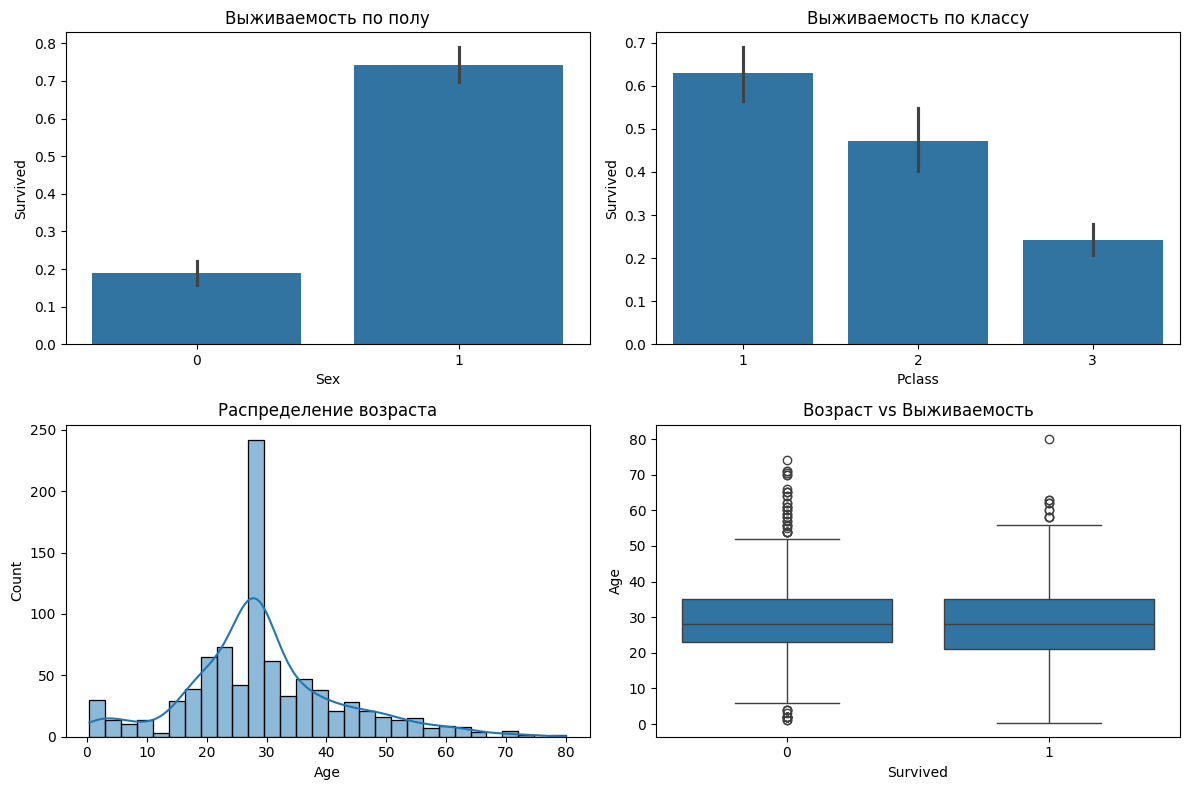

In [ ]:
# EDA
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.barplot(x='Sex', y='Survived', data=df, ax=axes[0,0])
axes[0,0].set_title('Выживаемость по полу')

sns.barplot(x='Pclass', y='Survived', data=df, ax=axes[0,1])
axes[0,1].set_title('Выживаемость по классу')

sns.histplot(df['Age'].dropna(), bins=30, kde=True, ax=axes[1,0])
axes[1,0].set_title('Распределение возраста')

sns.boxplot(x='Survived', y='Age', data=df, ax=axes[1,1])
axes[1,1].set_title('Возраст vs Выживаемость')

plt.tight_layout()
plt.show()

In [ ]:
# Создание модели
X = df.drop(columns=['Survived', 'Sex'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, y_pred):.3f}')
print(classification_report(y_test, y_pred))

Accuracy: 0.821
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       105
           1       0.78      0.78      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.82      0.82      0.82       179



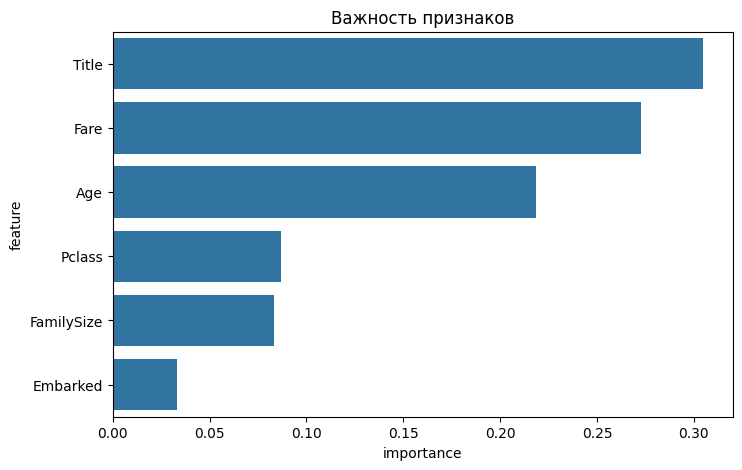

In [ ]:
# Важность признаков
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='importance', y='feature', data=importance)
plt.title('Важность признаков')
plt.show()


In [ ]:
# Подбор гиперпараметров
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f'Лучшие параметры: {grid_search.best_params_}')
print(f'Лучший CV score: {grid_search.best_score_:.3f}')

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
print(f'Accuracy на тесте: {accuracy_score(y_test, y_pred_best):.3f}')

Лучшие параметры: {'max_depth': 6, 'min_samples_split': 5, 'n_estimators': 300}
Лучший CV score: 0.837
Accuracy на тесте: 0.816


In [ ]:
# Сравнение моделей
models = {
    'Логистическая регрессия': LogisticRegression(max_iter=10000, random_state=42),
    'Дерево решений':          DecisionTreeClassifier(random_state=42),
    'Random Forest (default)': RandomForestClassifier(n_estimators=100, random_state=42),
    'Random Forest (tuned)':   RandomForestClassifier(
                                   n_estimators=300, max_depth=6,
                                   min_samples_split=5, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f'{name}: {acc:.3f}')

Логистическая регрессия: 0.754
Дерево решений: 0.777
Random Forest (default): 0.821
Random Forest (tuned): 0.816
